### Overview

The [WaterDetect algorithm](https://github.com/cordmaur/WaterDetect) uses unsupervised clustering on water-sensitive spectral indices to automatically detect open water bodies from satellite imagery — without any labeled training data.

In this notebook we adapt the WaterDetect workflow for a cloud-native Python stack. We start from the multiband composite prepared in the previous section and run a K-Means clustering on water-sensitive spectral indices and Identify the water cluster as the one with the highest mean MNDWI.

### Setup

Determine our runtime environment.


In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install rioxarray dask scikit-learn

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask.array as da
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import os
import rioxarray as rxr
import xarray as xr
from sklearn.cluster import KMeans

### Load Multiband Composite

Load the multiband composite saved by 01_preparing_composites.ipynb. The composite contains 11 bands: 6 raw spectral bands (red, green, blue, nir, swir16, swir22) and 5 precomputed indices (ndvi, ndbi, bsi, mndwi, ndwi).

In [ ]:
multiband_composite_path = os.path.join(data_folder, 'multiband_composite.tif')
if not os.path.exists(multiband_composite_path):
    print(f'Composite file not found at {multiband_composite_path}.',
          'Using default composite.')
    multiband_composite_path = (
        'https://storage.googleapis.com/spatialthoughts-public-data'
        '/python-remote-sensing/multiband_composite.tif')

band_names = ['red', 'green', 'blue', 'nir', 'swir16', 'swir22',
              'ndvi', 'ndbi', 'bsi', 'mndwi', 'ndwi', 'elevation', 'slope']
composite_da = rxr.open_rasterio(multiband_composite_path, masked=True)
composite_da = composite_da.assign_coords(band=band_names)
composite = composite_da.to_dataset('band')
composite

### Load Area of Interest

Read the file containing the city boundary.

In [ ]:
aoi_filepath = os.path.join(data_folder, 'aoi.geojson')

if not os.path.exists(aoi_filepath):
    print(f'AOI file not found at {aoi_filepath}. Using default AOI.')
    aoi_filepath = ('https://storage.googleapis.com/spatialthoughts-public-data'
                    '/python-remote-sensing/aoi.geojson')

aoi_gdf = gpd.read_file(aoi_filepath)
geometry = aoi_gdf.geometry.union_all()
geometry

Visualize the composite as a true-color image.

In [ ]:
rgb_da = composite[['red', 'green', 'blue']].to_array('band')
preview = rgb_da.rio.reproject(rgb_da.rio.crs, resolution=100)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(6, 6)
preview.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax,
    vmin=0, vmax=0.3)
ax.set_title(f'Sentinel-2 Composite')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

### Prepare WaterDetect Indices

The WaterDetect algorithm uses a three-band stack of water-sensitive indices as input to the clusterer.

- MNDWI: `(Green − SWIR1) / (Green + SWIR1)`
- NDWI: `(Green − NIR) / (Green + NIR)`
- MIR2:  `SWIR2`

Water has high NDWI and MNDWI values and low MIR2 reflectance, making this combination highly discriminative. Other band combinations are described in the [WaterDetect configuration reference](https://github.com/cordmaur/WaterDetect/blob/master/WaterDetect.ini).

NDWI and MNDWI are already available in the loaded composite. We add MIR2 as an alias for the SWIR2 band.

In [ ]:
composite['mir2'] = composite['swir22']
composite[['ndwi', 'mndwi', 'mir2']]

### Unsupervised Clustering

We sample pixels from the three-band index stack and train a K-Means clusterer. Here we use scikit-learn's `KMeans` with a fixed `n_clusters`. Adjust this value if water bodies are split across multiple clusters or merged with other land cover types.

First, we extract all valid (non-NaN) pixels and draw a random sample to train on.

In [ ]:
# Stack the three index bands into a (3, y, x) array
feature_da = composite[['ndwi', 'mndwi', 'mir2']].to_array('band')
features_3d = feature_da.values  # (3, y, x)

# Build a mask of pixels that are valid in all three bands
valid_mask = ~np.isnan(features_3d).any(axis=0)  # (y, x) boolean
features_valid = features_3d[:, valid_mask].T     # (n_valid, 3)

print(f'Total valid pixels: {len(features_valid):,}')

# Draw a random sample to train the clusterer
rng = np.random.default_rng(42)
sample_size = min(5000, len(features_valid))
idx = rng.choice(len(features_valid), size=sample_size, replace=False)
sample = features_valid[idx]
print(f'Training sample size: {len(sample):,}')

In [ ]:
n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
kmeans.fit(sample)
print(f'Trained KMeans with {n_clusters} clusters')

Apply the trained clusterer to all pixels using `map_blocks`.

In [ ]:
# Convert the feature stack to a Dask array
feature_da = composite[['ndwi', 'mndwi', 'mir2']].to_array('band')
feature_da = feature_da.chunk({'band': -1, 'y': 500, 'x': 500})
emb_dask = feature_da.data  # (bands, y, x)

# Transpose to (y, x, bands) then reshape to (y*x, bands)
emb_dask = da.moveaxis(emb_dask, 0, -1)
ny, nx, nb_feat = emb_dask.shape
emb_2d_dask = emb_dask.reshape(-1, nb_feat)
# Rechunk so each block has ALL bands — required by the classifier
emb_2d_rechunked = emb_2d_dask.rechunk({0: 'auto', 1: -1})

def predict_block(block, model):
    valid = ~np.isnan(block).any(axis=1)
    result = np.full(len(block), np.nan)
    if valid.any():
        result[valid] = model.predict(block[valid]).astype(float)
    return result

predicted_labels_1d = emb_2d_rechunked.map_blocks(
    predict_block,
    model=kmeans,
    dtype=np.float64,
    drop_axis=1,
)

predicted_labels_2d = predicted_labels_1d.reshape(ny, nx)

clustered = xr.DataArray(
    predicted_labels_2d,
    coords={'y': composite.y, 'x': composite.x},
    dims=['y', 'x'],
    name='cluster'
).rio.write_crs(composite.rio.crs)
clustered

In [ ]:
%%time
clustered = clustered.compute()

### Identify the Water Cluster

We compute the mean MNDWI for every cluster. Water bodies have distinctively high MNDWI values (typically > 0), so the cluster with the highest mean MNDWI is the water cluster.

In [ ]:
# Compute mean MNDWI for each cluster directly on the 2D spatial arrays
mndwi_da = composite['mndwi']

cluster_mndwi_mean = {}
for c in range(n_clusters):
    cluster_mndwi = mndwi_da.where(clustered == c)
    cluster_mndwi_mean[c] = float(cluster_mndwi.mean())

print('Mean MNDWI per cluster:')
for c, v in sorted(cluster_mndwi_mean.items()):
    marker = ' <-- water' if c == max(cluster_mndwi_mean, key=cluster_mndwi_mean.get) else ''
    print(f'  Cluster {c}: {v:+.4f}{marker}')

water_cluster = max(cluster_mndwi_mean, key=cluster_mndwi_mean.get)
print(f'\nWater cluster: {water_cluster}')

Select all pixels belonging to the water cluster.

In [ ]:
water_mask = (clustered == water_cluster).astype('float32')
water_mask = water_mask.where(~np.isnan(clustered))
water_mask = water_mask.rio.write_nodata(np.nan)
water_mask

### Visualize Results

Plot the RGB composite, the full cluster map, and the extracted water mask side by side.

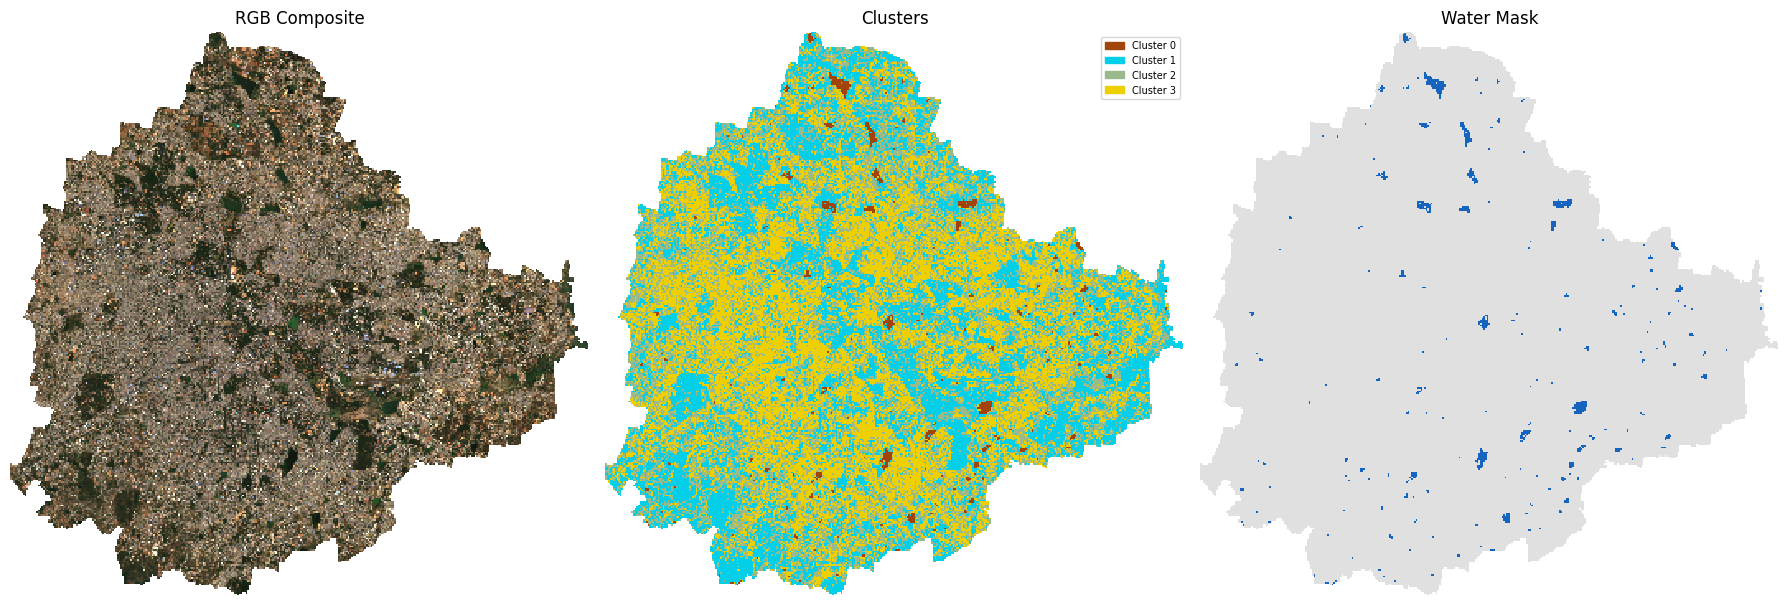

In [21]:
# Random distinct colors for each cluster
rng_colors = np.random.default_rng(0)
cluster_colors = rng_colors.random((n_clusters, 3))
cmap_clusters = mcolors.ListedColormap(cluster_colors)

# Low-resolution previews
preview_rgb      = composite[['red', 'green', 'blue']].to_array('band').rio.reproject(
    composite.rio.crs, resolution=100)
preview_clusters = clustered.rio.reproject(clustered.rio.crs, resolution=100)
preview_water    = water_mask.rio.reproject(water_mask.rio.crs, resolution=100)

fig, axes = plt.subplots(1, 3)
fig.set_size_inches(18, 6)

preview_rgb.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=axes[0], vmin=0, vmax=0.3)
axes[0].set_title('RGB Composite')

preview_clusters.plot.imshow(
    ax=axes[1],
    cmap=cmap_clusters,
    vmin=-0.5, vmax=n_clusters - 0.5,
    add_colorbar=False)
# Add cluster number labels to legend
handles = [mpatches.Patch(color=cluster_colors[c], label=f'Cluster {c}') for c in range(n_clusters)]
axes[1].legend(handles=handles, loc='upper right', fontsize=7)
axes[1].set_title('Clusters')

water_cmap = mcolors.ListedColormap(['#e0e0e0', '#1565C0'])
preview_water.plot.imshow(
    ax=axes[2],
    cmap=water_cmap,
    vmin=0, vmax=1,
    add_colorbar=False)
axes[2].set_title('Water Mask')

for ax in axes:
    ax.set_axis_off()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### Save the Water Mask

Save the result as a Cloud-Optimized GeoTIFF to the configured output folder.

In [ ]:
output_file = f'water_mask_{year}.tif'
output_path = os.path.join(output_folder, output_file)
water_mask.rio.to_raster(output_path, driver='COG')
print(f'Saved {output_path}')

### Exercise

The WaterDetect algorithm works with any combination of water-sensitive bands. The [WaterDetect configuration file](https://github.com/cordmaur/WaterDetect/blob/master/WaterDetect.ini) lists several alternative band combinations.

Try replacing the `[ndwi, mndwi, mir2]` feature stack with `[ndwi, mndwi, nir]` and compare the results. Which combination produces a cleaner water mask for Bangalore?